In [2]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
from scipy.stats import spearmanrho
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot, get_centroid
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons


In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 8
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 0
    signal_metric = "cosine_cnt"
    model_metric = "cosine_cnt"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    max_lag = 200
    analysis_type = "RSA"
    tick_step = 100
    min_peak_percent = .2
    negative_lim = .5
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

# SUBJECTS AVERAGE

In [12]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
all_peaks = []
all_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
all_max_avgs = []
for i_sub in config["subjects"][:10]:
    sub_max = []
    for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        try:
            res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
            res = loadmat(res_path)["RSA"]    
            lagplot = get_lagplot(res, cfg.max_lag)
            sub_max.append(np.max(lagplot))
            sub_counter +=1
        except FileNotFoundError:
            print_wise(f"sub={i_sub} layer={l} not found")
            continue
    all_max_avgs.append(sub_max)

<Figure size 1200x600 with 0 Axes>

In [16]:
all_max_avgs = np.array(all_max_avgs)

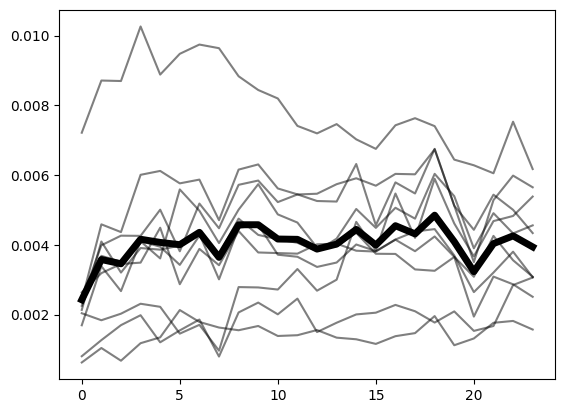

In [28]:
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, all_max_avgs.shape[0]))

plt.figure()
for i, line in enumerate(all_max_avgs):
    plt.plot(line, color="black", alpha=.5)
plt.plot(np.mean(all_max_avgs, axis=0), linewidth=5, color="k")
plt.show();

In [6]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
all_peaks = []
all_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
rhos = []
model_fit = []
for i_sub in config["subjects"][:10]:
    avg_lagplot = np.zeros(cfg.max_lag*2 +1)
    layers_counter = 0
    layers_idx = []
    centroids = []
    for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        try:
            res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
            res = loadmat(res_path)["RSA"]    
            lagplot = get_lagplot(res, cfg.max_lag)
            avg_lagplot+=lagplot
            layers_counter +=1
        except FileNotFoundError:
            print_wise(f"sub={i_sub} layer={l} not found")
            continue
        if np.max(lagplot)>0:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            centroids.append(centroid_lag)
            layers_idx.append(idx)
    if len(centroids)>3:
        rhos.append(spearmanrho(centroids, layers_idx).statistic)
        subject_fit = np.max(avg_lagplot/layers_counter)
        model_fit.append(subject_fit)
        

In [7]:
np.round(rhos, 3)

array([ 0.675,  0.903,  0.064,  0.935,  0.589,  0.494, -0.165,  0.367,
       -0.17 ,  0.899])

In [8]:
np.round(model_fit, 5)

array([0.00416, 0.00512, 0.00329, 0.00385, 0.00373, 0.00525, 0.00186,
       0.00367, 0.00137, 0.00786])

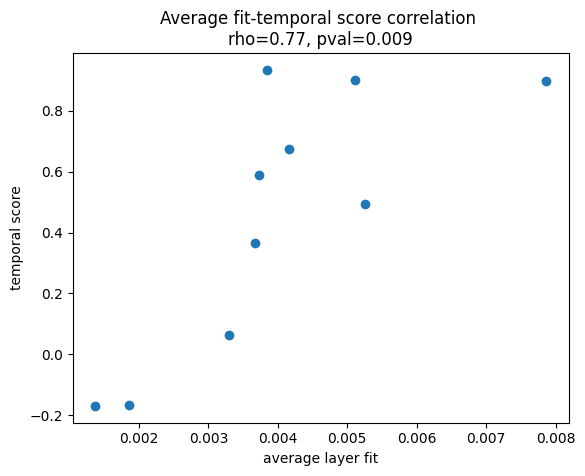

In [9]:
plt.scatter(model_fit, rhos)
print()
plt.ylabel("temporal score")
plt.xlabel("average layer fit")
fit_score_rho = spearmanrho(model_fit, rhos)
plt.title(f"Average fit-temporal score correlation \nrho={round(fit_score_rho.statistic, 2)}, pval={round(fit_score_rho.pvalue, 3)}");


0.0006478271325727525
SignificanceResult(statistic=np.float64(0.12948111799903805), pvalue=np.float64(0.2963432367048509))


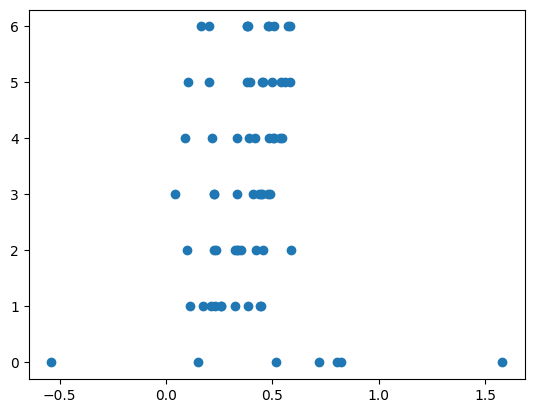

In [48]:
all_centroids = np.stack(all_centroids)
plt.scatter(all_centroids[:,1], all_centroids[:,0])
print(np.corrcoef(all_centroids[:,1], all_centroids[:,0])[0,1])
print(spearmanrho(all_centroids[:,1], all_centroids[:,0]))

/Users/tizianocausin/Desktop/project1917-26/.venv/lib/python3.14/site-packages/scipy/stats/_correlation.py:384: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = stats.pearsonr(rx, ry, method=method, alternative=alternative, axis=axis)


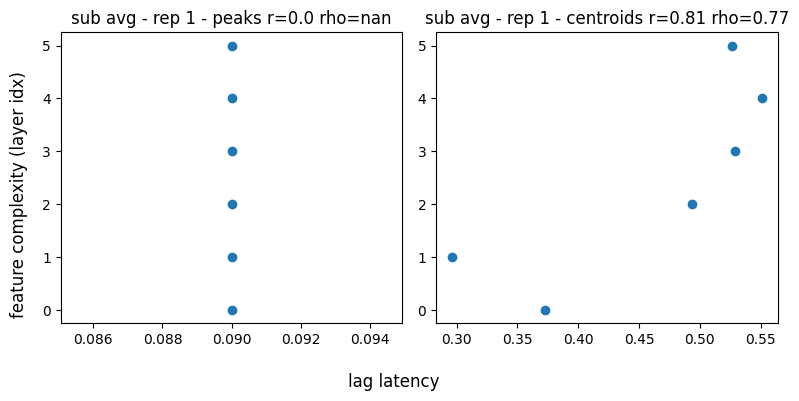

In [49]:
from useful_stuff.general_utils.utils import spearman
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearmanrho(np.arange(len(peaks)), np.array(peaks)).statistic,2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"sub avg - rep {cfg.repetition+1} - peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearmanrho(np.arange(len(peaks)), np.array(centroids)).statistic, 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"sub avg - rep {cfg.repetition+1} - centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

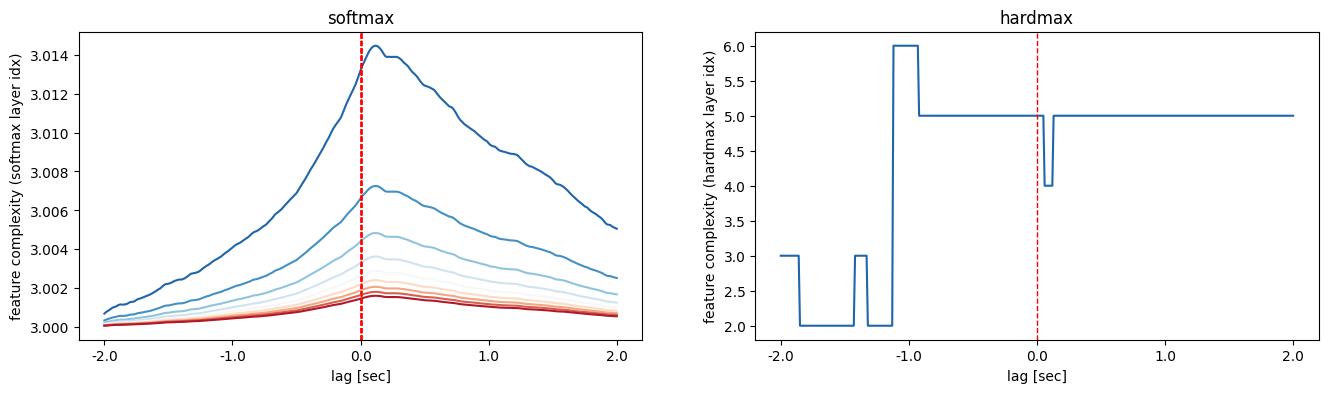

In [13]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax_lp = []

temp = .001
temp_range = np.arange(0.1, 1, 0.1)
cmap = truncate_colormap(plt.cm.RdBu)
colors = cmap(np.linspace(0, 1, len(temp_range)))[::-1]
fig, ax = plt.subplots(1,2, figsize=(16,4))

for idx, temp in enumerate(temp_range):
    softmax_lp = []
    for t in range(lps.shape[1]):
        softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
        if temp==temp_range[-1]:
            hardmax_lp.append(np.argmax(lps[:,t]))
    # plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax[0].plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax[0].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
    ax[0].set_xticks(ticks, ticks_labels)
    ax[0].set_xlabel("lag [sec]")
    ax[0].set_ylabel("feature complexity (softmax layer idx)")
    ax[0].set_title("softmax")
ax[1].plot(hardmax_lp, color=colors[0])
ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
ax[1].set_xticks(ticks, ticks_labels)
ax[1].set_xlabel("lag [sec]")
ax[1].set_ylabel("feature complexity (hardmax layer idx)")
ax[1].set_title("hardmax");